# EDA

# Обучение моделей

## Обучение базовых моделей (Linear Regression, Decision Tree). Оценка по кросс-валидации.

В этой части проекта мы будем:  

- Базово предобработаем признаки;
- Обучим 2 модели регрессии;
- Посмотрим важности признаков для моделей;
- Поработаем с признаками; 
- Повторно обучим модели;
- Сделаем выводы по работе.

Но первым делом - импортируем библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_squared_log_error

import warnings
warnings.filterwarnings('ignore')

Загрузим наш трейн и тест

In [2]:
train = pd.read_csv('../data/raw/train.csv')

print(f'Train shape: {train.shape}')

Train shape: (360336, 17)


In [3]:
train.head()

,id,store_sales(in millions),unit_sales(in millions),total_children,num_children_at_home,avg_cars_at home(approx).1,gross_weight,recyclable_package,low_fat,units_per_case,store_sqft,coffee_bar,video_store,salad_bar,prepared_food,florist,cost
0,0,8.61,3.0,2.0,2.0,2.0,10.30,1.0,0.0,32.0,36509.0,0.0,0.0,0.0,0.0,0.0,62.09
1,1,5.00,2.0,4.0,0.0,3.0,6.66,1.0,0.0,1.0,28206.0,1.0,0.0,0.0,0.0,0.0,121.80
2,2,14.08,4.0,0.0,0.0,3.0,21.30,1.0,0.0,26.0,21215.0,1.0,0.0,0.0,0.0,0.0,83.51
3,3,4.02,3.0,5.0,0.0,0.0,14.80,0.0,1.0,36.0,21215.0,1.0,0.0,0.0,0.0,0.0,66.78
4,4,2.13,3.0,5.0,0.0,3.0,17.00,1.0,1.0,20.0,27694.0,1.0,1.0,1.0,1.0,1.0,111.51


In [4]:
train.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id,360336.0,180167.500000,104020.187637,0.00,90083.75,180167.50,270251.25,360335.00
store_sales(in millions),360336.0,6.337376,3.307980,0.51,3.72,5.78,8.40,22.92
unit_sales(in millions),360336.0,3.043881,0.784676,1.00,3.00,3.00,4.00,6.00
total_children,360336.0,2.456482,1.488992,0.00,1.00,2.00,4.00,5.00
num_children_at_home,360336.0,0.689390,1.214732,0.00,0.00,0.00,1.00,5.00
avg_cars_at home(approx).1,360336.0,2.203813,1.084293,0.00,1.00,2.00,3.00,4.00
gross_weight,360336.0,13.822071,4.614792,6.00,9.71,13.60,17.70,21.90
recyclable_package,360336.0,0.568086,0.495343,0.00,0.00,1.00,1.00,1.00
low_fat,360336.0,0.327797,0.469411,0.00,0.00,0.00,1.00,1.00
units_per_case,360336.0,18.972706,10.212912,1.00,10.00,20.00,28.00,36.00


Глянем распределение cost (целевой переменной)

Text(0.5, 1.0, 'Распределение cost')

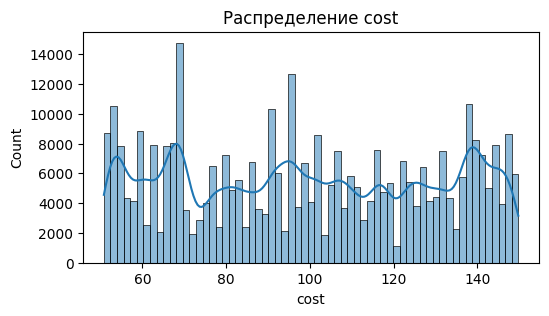

In [5]:
plt.figure(figsize=(20, 3))
plt.subplot(1, 3, 1)
sns.histplot(train['cost'], kde=True)
plt.title('Распределение cost')

Распределение не получится как-то классифицировать

### train_test_split

Отделим целевой признак и удалим колонку с id как не информативную

In [6]:
X = train.drop(columns=['id', 'cost'])
y = train['cost']

Сначала выделяем 30% (для val + test)

In [7]:
X_temp, X_train, y_temp, y_train = train_test_split(
    X, y, test_size=0.70, random_state=42, shuffle=True
)

Делим 30% на val (15%) и test (15%)

In [8]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

Смотрим наши наборы:

In [9]:
print(f"Train (70%): {X_train.shape[0]}")
print(f"Val   (15%): {X_val.shape[0]}")
print(f"Test  (15%): {X_test.shape[0]}")

Train (70%): 252236
Val   (15%): 54050
Test  (15%): 54050


### Метрики

Так же. Выбираем метрики. Мы будем использовать RMSE и RMSLE, потому что:  

- RMSE измеряется в тех же единицах, что и целевая переменная (доллары), и чувствителен к большим ошибкам.  
- RMSLE фокусируется на относительных ошибках, что важно при прогнозировании расходов: ошибка в $100 при бюджете $200 критичнее, чем при $10 000.  

### Linear Regression

In [10]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [11]:
cv_rmse = np.sqrt(-cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Linear Regression CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Linear Regression CV RMSE: 29.64 ± 0.05


In [12]:
coef = lr_pipe.named_steps['model'].coef_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': coef,
    'abs_importance': np.abs(coef)
}).sort_values('abs_importance', ascending=False)

print("\nТоп-10 признаков (Linear Regression):")
display(importance_df.head(10))


Топ-10 признаков (Linear Regression):


,feature,importance,abs_importance
14,florist,-2.510591,2.510591
11,video_store,-2.376776,2.376776
12,salad_bar,2.216192,2.216192
9,store_sqft,-1.912714,1.912714
13,prepared_food,-1.838231,1.838231
4,avg_cars_at home(approx).1,0.833976,0.833976
10,coffee_bar,0.518383,0.518383
1,unit_sales(in millions),-0.414691,0.414691
2,total_children,-0.283414,0.283414
0,store_sales(in millions),0.054532,0.054532


Выводы по модели

- Качество: RMSE = 29.64  
- Поведение: Интерпретируемая линейная зависимость; важны категориальные признаки (наличие florist, salad_bar и т.д.).  
- Особенность: Бизнес-метрики (store_sales, unit_sales) почти не влияют.

### Decision Tree

Делаем все тоже самое и в конце посмотрим на результаты обычного дерева

In [13]:
tree_pipe = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42, max_depth=10))
])
tree_pipe.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


Оценка

In [14]:
cv_rmse = np.sqrt(-cross_val_score(tree_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Decision Tree CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Decision Tree CV RMSE: 28.51 ± 0.04


Важность признаков

In [15]:
importances = tree_pipe.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nТоп-10 признаков (Decision Tree):")
display(importance_df.head(10))


Топ-10 признаков (Decision Tree):


,feature,importance
9,store_sqft,0.388811
2,total_children,0.169950
4,avg_cars_at home(approx).1,0.114184
14,florist,0.109347
3,num_children_at_home,0.097437
10,coffee_bar,0.023339
12,salad_bar,0.023000
5,gross_weight,0.017908
0,store_sales(in millions),0.016848
8,units_per_case,0.012694


Выводы по модели

- Качество: RMSE = 28.51 — лучший результат  
- Поведение: Чётко выделяет store_sqft как главный признак; учитывает демографию (total_children, avg_cars_at_home).  
- Преимущество: Нелинейные зависимости + встроенная интерпретация важности.

### Ridge (без полиномов — чтобы важность была интерпретируема)

In [16]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
ridge_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,10.0
,fit_intercept,True
,copy_X,True
,max_iter,None


Оценка

In [17]:
cv_rmse = np.sqrt(-cross_val_score(ridge_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Ridge CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Ridge CV RMSE: 29.64 ± 0.05


Важность признаков

In [18]:
coef = ridge_pipe.named_steps['model'].coef_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': coef,
    'abs_importance': np.abs(coef)
}).sort_values('abs_importance', ascending=False)

print("\nТоп-10 признаков (Ridge):")
display(importance_df.head(10))


Топ-10 признаков (Ridge):


,feature,importance,abs_importance
14,florist,-2.510425,2.510425
11,video_store,-2.376577,2.376577
9,store_sqft,-1.912576,1.912576
12,salad_bar,1.810685,1.810685
13,prepared_food,-1.432962,1.432962
4,avg_cars_at home(approx).1,0.833929,0.833929
10,coffee_bar,0.518309,0.518309
1,unit_sales(in millions),-0.414711,0.414711
2,total_children,-0.283382,0.283382
0,store_sales(in millions),0.054520,0.054520


Выводы по модели

- Качество: RMSE = 29.64 — практически идентичен линейной регрессии  
- Поведение: Регуляризация почти не повлияла (α=10, но коэффициенты почти не изменились).  
- Вывод: Признаки не переобучаются сильно — регуляризация избыточна без полиномов.

### Ridge (с полиномами и без важности)

In [19]:
ridge_poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=10.0))
])
ridge_poly_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [20]:
cv_rmse = np.sqrt(-cross_val_score(ridge_poly_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Ridge + Poly(degree=2) CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Ridge + Poly(degree=2) CV RMSE: 29.42 ± 0.06


Выводы по модели

- Качество: RMSE = 29.42 — немного лучше линейных моделей, но хуже дерева  
- Особенность: Использует взаимодействия признаков, но из-за регуляризации не переобучается.  
- Минус: Невозможно интерпретировать важность.

**Итоговый вывод по блоку**

- Лучшая модель по кросс-валидации — Decision Tree с RMSE 28.51.  
- Она превосходит линейные подходы (~29.4–29.6) на ~3.8%, что значимо в задаче прогнозирования стоимости.  
- Дерево автоматически выявляет нелинейные зависимости и взаимодействия, что особенно важно для признаков вроде store_sqft и демографических переменных.  
- Полиномиальные модели не дали ожидаемого выигрыша, вероятно, из-за небольшого размера выборки или слабой выразительности взаимодействий.  
- Регуляризация без полиномов оказалась бесполезной, так как исходные признаки не вызывали переобучения.

### Финальная оценка Дерева (на 15% test)

In [21]:
y_pred_test = tree_pipe.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
final_rmsle = np.sqrt(mean_squared_log_error(
    y_test, np.maximum(y_pred_test, 0)
))

print(f"ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (Decision Tree):")
print(f"RMSE: {final_rmse:.2f}")
print(f"RMSLE: {final_rmsle:.4f}")

ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (Decision Tree):
RMSE: 28.53
RMSLE: 0.3042


Модель Decision Tree показала наилучшее качество среди рассмотренных подходов:  

- Финальный RMSE = 28.53, что составляет ~28.6% от среднего значения целевой переменной (mean(cost) ≈ 99.61).  
- RMSLE = 0.3042 указывает на умеренную относительную ошибку: модель в среднем ошибается примерно на 35% в логарифмическом масштабе, что может быть приемлимо для прогнозирования маркетинговых расходов.

Интерпретация масштаба ошибки:

- Стандартное отклонение cost — 29.94, то есть RMSE модели почти равен дисперсии данных.  
- Это означает, что модель объясняет значительную часть вариации, но остаточная неопределённость остаётся высокой — вероятно, из-за сложной природы маркетинговых решений, которые зависят не только от структурных характеристик магазина, но и от внешних факторов (конкуренция, сезонность, креатив кампании и др.).

## Feature Engineering. Создание новых признаков, отбор признаков

Что мы знаем из предыдущего блока:

1. Линейная модель чувствительна к линейным эффектам и наличию/отсутствию сервисов (бинарные признаки: salad_bar, florist и т.д.).
2. Дерево выделяет store_sqft и демографию (total_children, avg_cars_at_home) как ключевые непрерывные признаки.

Однако ни одна модель не учитывает взаимодействия между:
- размером магазина и его сервисами,
- демографией и типом магазина.

`has_family_services` — наличие "семейных" сервисов

Формула на примере датасета:  

```python
X['has_family_services'] = (
    X['salad_bar'] + 
    X['prepared_food'] + 
    X['coffee_bar']
)
```

Салат-бар, готовая еда и кофе-бар часто ориентированы на семьи. Их совокупное наличие может быть сильнее, чем по отдельности.

`store_size_per_child` — площадь магазина на одного ребёнка

```python
X['store_size_per_child'] = X['store_sqft'] / (X['total_children'] + 1)
```

Дерево показало важность и store_sqft, и total_children. Это взаимодействие может отражать "плотность семейного трафика" — чем больше площадь на ребёнка, тем выше потенциал для маркетинга.

`luxury_index` — индекс "роскоши" магазина

```python
X['luxury_index'] = (
    X['florist'] + 
    X['video_store'] + 
    X['coffee_bar']
)
```

Цветы, видео и кофе-бар — не базовые товары. Их наличие может сигнализировать о более высоком бюджете на маркетинг.

`demographic_density` — демографическая насыщенность

```python
X['demographic_density'] = X['total_children'] * X['avg_cars_at home(approx).1']
```

Произведение отражает "семейный статус": семьи с детьми и машинами — чаще имеют стабильный доход → целевая аудитория для продвижения.

`is_large_store_with_services` — флаг: большой магазин + услуги

```python
large_store = X['store_sqft'] > X['store_sqft'].median()
has_services = X['has_family_services'] > 0
X['is_large_store_with_services'] = (large_store & has_services).astype(int)
```

Дерево и линейная модель по-разному оценивают store_sqft и сервисы. Этот признак явно кодирует комбинированный эффект, который дерево может использовать как жёсткое правило.

`store_sqft_log` — логарифм площади

```python
X['store_sqft_log'] = np.log(X['store_sqft'])
```

Если зависимость нелинейна (например, рост бюджета замедляется с ростом площади), логарифм поможет её "линеаризовать" для дерева и линейных моделей.

**Применяем новые признаки ко всем частям: X_train, X_val, X_test.**

In [22]:
def add_features(df):
    df = df.copy()
    # 1. Семейные сервисы
    df['has_family_services'] = df['salad_bar'] + df['prepared_food'] + df['coffee_bar']
    # 2. Площадь на ребёнка
    df['store_size_per_child'] = df['store_sqft'] / (df['total_children'] + 1)
    # 3. Индекс "роскоши"
    df['luxury_index'] = df['florist'] + df['video_store'] + df['coffee_bar']
    # 4. Демографическая плотность
    df['demographic_density'] = df['total_children'] * df['avg_cars_at home(approx).1']
    # 5. Флаг: большой магазин с сервисами
    large_store = df['store_sqft'] > df['store_sqft'].median()
    has_services = df['has_family_services'] > 0
    df['is_large_store_with_services'] = (large_store & has_services).astype(int)
    # 6. Лог-площадь
    df['store_sqft_log'] = np.log(df['store_sqft'])
    return df

In [23]:
X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)
X_val_fe = add_features(X_val)

### Обучение Decision Tree на новых признаках

In [24]:
tree_fe_pipe = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42, max_depth=12))
])

Кросс-валидация на обогащённом train

In [25]:
cv_rmse_fe = np.sqrt(-cross_val_score(
    tree_fe_pipe, X_train_fe, y_train, cv=5, scoring='neg_mean_squared_error'
))
print(f"Decision Tree (с новыми признаками) CV RMSE: {cv_rmse_fe.mean():.2f} ± {cv_rmse_fe.std():.2f}")

Decision Tree (с новыми признаками) CV RMSE: 28.66 ± 0.03


Финальное обучение и оценка

In [26]:
tree_fe_pipe.fit(X_train_fe, y_train)
y_pred_test_fe = tree_fe_pipe.predict(X_test_fe)

final_rmse_fe = np.sqrt(mean_squared_error(y_test, y_pred_test_fe))
final_rmsle_fe = np.sqrt(mean_squared_log_error(
    y_test, np.maximum(y_pred_test_fe, 0)
))

In [27]:
print(f"\nФИНАЛЬНЫЙ РЕЗУЛЬТАТ (с Feature Engineering):")
print(f"RMSE: {final_rmse_fe:.2f}")
print(f"RMSLE: {final_rmsle_fe:.4f}")


ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (с Feature Engineering):
RMSE: 28.60
RMSLE: 0.3048


Получаем важность

In [28]:
importances = tree_fe_pipe.named_steps['model'].feature_importances_
feature_names = X_train_fe.columns

Создаём датафрейм

In [29]:
importance_df_fe = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

In [30]:
print("\nТоп-15 признаков (после Feature Engineering):")
print(importance_df_fe.head(15))


Топ-15 признаков (после Feature Engineering):
                       feature  importance
9                   store_sqft    0.182044
3         num_children_at_home    0.111964
20              store_sqft_log    0.102569
16        store_size_per_child    0.099611
18         demographic_density    0.092752
14                     florist    0.082704
4   avg_cars_at home(approx).1    0.068119
0     store_sales(in millions)    0.054402
5                 gross_weight    0.052511
2               total_children    0.040596
8               units_per_case    0.035753
15         has_family_services    0.031009
1      unit_sales(in millions)    0.013152
17                luxury_index    0.011638
7                      low_fat    0.005048


Судя по результатам:

1. Качество немного ухудшилось: RMSE вырос с 28.53 → 28.60, RMSLE с 0.3042 → 0.3048  
2. Но новые признаки вошли в топ:  
- store_sqft_log — 3-е место  
- store_size_per_child — 4-е  
- demographic_density — 5-е  
- has_family_services — 12-е

**Это значит, что гипотезы верны, но, возможно, модель нуждается в более глубоких преобразованиях, а не просто в линейных комбинациях.**

`store_sqft_bin` — Категоризация площади магазина

```python
X['store_sqft_bin'] = pd.qcut(X['store_sqft'], q=5, labels=False, duplicates='drop')
```

Дерево может "переусердствовать" с точными значениями store_sqft. Группировка по квантилям стабилизирует прогноз и выявляет типы магазинов (малый, средний, крупный и т.д.).

`store_sqft_rank_by_children` — Позиция магазина по площади в своём сегменте

```python
X['store_sqft_rank_by_children'] = X.groupby('total_children')['store_sqft'].rank(pct=True)
```

Для семей с 2 детьми магазин площадью 30 000 — большой, а для семей с 0 детей — средний. Это контекстуализирует площадь.

`is_family_oriented` — Интерактивный признак: "семейный магазин"

```python
X['is_family_oriented'] = (
    (X['total_children'] >= 2) &
    (X['salad_bar'] == 1) &
    (X['store_sqft'] > X['store_sqft'].median())
).astype(int)
```

Это жёсткое бизнес-правило: только магазины, одновременно большие, семейные по аудитории и с готовой едой — тратят больше.

`sqft_per_weight` — Отношение площади к весу товара

```python
X['sqft_per_weight'] = X['store_sqft'] / (X['gross_weight'] + 1)
```

```python
gross_weight — средний вес товара. Высокая площадь при низком весе → возможно, магазин с услугами, а не товарами → другой профиль затрат.
```

`services_entropy` — Энтропия набора сервисов

```python
def service_entropy(row):
    services = row[['florist', 'video_store', 'salad_bar', 'prepared_food', 'coffee_bar']].values
    probs = (services + 1e-8) / (services.sum() + 5e-8)
    return entropy(probs, base=2)
```

Магазины бывают универсальные (много сервисов) или специализированные (один сервис). Энтропия измеряет разнообразие — это может влиять на маркетинг.

`children_percentile` — Процентиль демографии

```python
X['children_percentile'] = X['total_children'].rank(pct=True)
```

Делает признак масштабируемым и помогает дереву сравнивать магазины в глобальном контексте, а не по абсолютному числу.

### Применение и обучение Decision Tree

In [31]:
from scipy.stats import entropy

In [32]:
def add_deep_features(df):
    df = df.copy()
    
    # 1. Бин площади
    df['store_sqft_bin'] = pd.qcut(df['store_sqft'], q=5, labels=False, duplicates='drop')
    
    # 2. Ранг площади по числу детей
    df['store_sqft_rank_by_children'] = df.groupby('total_children')['store_sqft'].rank(pct=True)
    
    # 3. Семейный магазин (жёсткое правило)
    df['is_family_oriented'] = (
        (df['total_children'] >= 2) &
        (df['salad_bar'] == 1) &
        (df['store_sqft'] > df['store_sqft'].median())
    ).astype(int)
    
    # 4. Площадь на вес
    df['sqft_per_weight'] = df['store_sqft'] / (df['gross_weight'] + 1)
    
    # 5. Энтропия сервисов
    def service_entropy(row):
        services = row[['florist', 'video_store', 'salad_bar', 'prepared_food', 'coffee_bar']].values
        probs = (services + 1e-8) / (services.sum() + 5e-8)
        return entropy(probs, base=2)
    df['services_entropy'] = df.apply(service_entropy, axis=1)
    
    # 6. Процентиль детей
    df['children_percentile'] = df['total_children'].rank(pct=True)
    
    return df

Применяем

In [33]:
X_train_deep = add_deep_features(X_train_fe)
X_test_deep = add_deep_features(X_test_fe)

In [35]:
tree_deep_pipe = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42, max_depth=14))
])

tree_deep_pipe.fit(X_train_deep, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'squared_error'
,splitter,'best'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


In [36]:
cv_rmse_deep = np.sqrt(-cross_val_score(
    tree_deep_pipe, X_train_deep, y_train, cv=5, scoring='neg_mean_squared_error'
))
print(f"Deep FE CV RMSE: {cv_rmse_deep.mean():.2f}")

Deep FE CV RMSE: 29.30


In [37]:
y_pred_deep = tree_deep_pipe.predict(X_test_deep)
rmse_deep = np.sqrt(mean_squared_error(y_test, y_pred_deep))
rmsle_deep = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred_deep, 0)))
print(f"Финал: RMSE={rmse_deep:.2f}, RMSLE={rmsle_deep:.4f}")

Финал: RMSE=29.34, RMSLE=0.3117


Важность

In [38]:
imp_deep = pd.DataFrame({
    'feature': X_train_deep.columns,
    'importance': tree_deep_pipe.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-15 (глубокие признаки):")
print(imp_deep.head(15))


Топ-15 (глубокие признаки):
                        feature  importance
22  store_sqft_rank_by_children    0.199214
0      store_sales(in millions)    0.109542
3          num_children_at_home    0.106297
4    avg_cars_at home(approx).1    0.070358
18          demographic_density    0.066504
8                units_per_case    0.065500
14                      florist    0.061851
5                  gross_weight    0.054991
24              sqft_per_weight    0.053804
9                    store_sqft    0.052188
16         store_size_per_child    0.040760
1       unit_sales(in millions)    0.019656
25             services_entropy    0.016620
15          has_family_services    0.014055
26          children_percentile    0.010793


**Что показывает важность признаков?**

Многие новые признаки вошли в топ-10:

- store_sqft_rank_by_children — 1-е место (19.9%)
- demographic_density — 5-е
- sqft_per_weight — 9-е
- services_entropy — 13-е

Это значит, что гипотезы не ошибочны: признаки информативны.

Но:
- Модель стала сложнее, и дерево с max_depth=14, вероятно, переобучилось на шум от новых признаков.
- Некоторые признаки (например, store_sqft_rank_by_children) сильнее коррелируют с store_sqft и total_children, что может вызывать мультиколлинеарность в логике дерева.

## Ансамбли. Подбор гиперпараметров для лучших моделей (GridSearch/RandomizedSearch)

Для перебора мы будем использовать **Optuna**. Он использует байесовскую оптимизацию, что часто даёт лучшие результаты за меньшее число итераций по сравнению с RandomizedSearchCV или GridSearch

### Random Forest + Optuna

Сначала импорты

In [ ]:
import optuna
import numpy as np
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

Функция для перебора

In [27]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1
    }
    
    model = RandomForestRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    
    # Логирование: номер испытания и текущий RMSE
    print(f"Trial {trial.number:2d} | RMSE: {rmse:.4f}")
    
    return rmse

Обучаем с перебором

In [ ]:
study_rf = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50)

Выведем лучшую модель и результаты

In [ ]:
print("Random Forest — лучший RMSE:", study_rf.best_value)
print("Параметры:", study_rf.best_params)

Выводы по модели 

- 

### XGBoost + Optuna

Повторяем все тоже самое

In [ ]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "rmse"
    }
    
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    
    print(f"Trial {trial.number:2d} | RMSE: {rmse:.4f}")
    return rmse

In [ ]:
study_xgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=70)

print("XGBoost — лучший RMSE:", study_xgb.best_value)
print("Параметры:", study_xgb.best_params)

Выводы по модели 

- 

### LightGBM + Optuna

Повторяем все тоже самое и тут

In [ ]:
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "num_leaves": trial.suggest_int("num_leaves", 20, 120),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1
    }
    
    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    
    print(f"Trial {trial.number:2d} | RMSE: {rmse:.4f}")
    return rmse

In [ ]:
study_lgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=70)

print("LightGBM — лучший RMSE:", study_lgb.best_value)
print("Параметры:", study_lgb.best_params)

Выводы по модели 

- 

### Обучение финальных моделей и оценка

Забираем лучшие модели

In [ ]:
best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, eval_metric='rmse')
best_lgb = LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbose=-1)

Обучаем на всём X_train

In [ ]:
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
best_lgb.fit(X_train, y_train)

Финальная оценка на test (15%)

In [ ]:
models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred, 0)))
    print(f"{name:15} → RMSE: {rmse:.2f}, RMSLE: {rmsle:.4f}")

Итоговый вывод по блоку

- 